# Cross-Layer Perturbation Comparison

Each section shows results for one perturbation type.
Within each section there are **two plots**:
- **SGD-delay**: compares 1st hidden layer vs 2nd hidden layer under the delay-trained model.
- **SGD (no delay)**: compares 1st hidden layer vs 2nd hidden layer under the baseline model.

Line style encodes layer: solid filled-circle (●) = 1st layer, dashed ×  = 2nd layer.  
Colour encodes dataset variant: **Whole** (blue), **Part** (green), **Norm** (red).

In [1]:
import json
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}
DATASETS = ["Whole", "Part", "Norm"]


def load_sweep(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Return (x_values, means_pct, stds_pct) from a sweep results JSON (int keys)."""
    with open(path) as fh:
        raw = json.load(fh)
    xs = sorted(int(k) for k in raw)
    means = np.array([raw[str(x)]["mean"] for x in xs]) * 100
    stds  = np.array([raw[str(x)]["std"]  for x in xs]) * 100
    return xs, means, stds


def load_sweep_float(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Like load_sweep but treats result-keys as floats (for p_d values)."""
    with open(path) as fh:
        raw = json.load(fh)
    items = sorted(((float(k), k) for k in raw), key=lambda p: p[0])
    xs    = [p[0] for p in items]
    means = np.array([raw[k]["mean"] for _, k in items]) * 100
    stds  = np.array([raw[k]["std"]  for _, k in items]) * 100
    return xs, means, stds


def load_reversal_sweep(
    path: pathlib.Path, condition: str,
) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Load one condition ('no_reversal' or 'reversal') from an inverse JSON."""
    with open(path) as fh:
        raw = json.load(fh)
    cond  = raw[condition]
    items = sorted(((float(k), k) for k in cond), key=lambda p: p[0])
    xs    = [p[0] for p in items]
    means = np.array([cond[k]["mean"] for _, k in items]) * 100
    stds  = np.array([cond[k]["std"]  for _, k in items]) * 100
    return xs, means, stds


def plot_cross_layer(
    ax,
    layer1_data: dict,   # {dataset: (xs, means, stds)}
    layer2_data: dict,
    title: str,
    xlabel: str,
    xlim: tuple,
):
    """Overlay layer-1 (solid ●) and layer-2 (dashed ×) on a single axes."""
    for key in DATASETS:
        xs, m, std = layer1_data[key]
        ax.plot(xs, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
        ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.12)

        xs, m, std = layer2_data[key]
        ax.plot(xs, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
        ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.08)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_xlim(*xlim)
    ax.set_ylim(0, None)
    ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)


def add_legend(ax):
    h_l1    = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                            markersize=5, linewidth=1.8, label="1st layer")
    h_l2    = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                            markersize=6, linewidth=1.8, label="2nd layer")
    h_whole = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
    h_part  = mlines.Line2D([], [], color=COLORS["Part"],  linewidth=2.5, label="Part")
    h_norm  = mlines.Line2D([], [], color=COLORS["Norm"],  linewidth=2.5, label="Norm")
    ax.legend(handles=[h_l1, h_l2, h_whole, h_part, h_norm],
              loc="upper right", framealpha=0.9, ncol=2)

## 3A: Per-Spike Jitter — Cross-Layer

Independent Gaussian noise (σ ms) added to spikes. Sweep: σ = 0 → 25 ms.

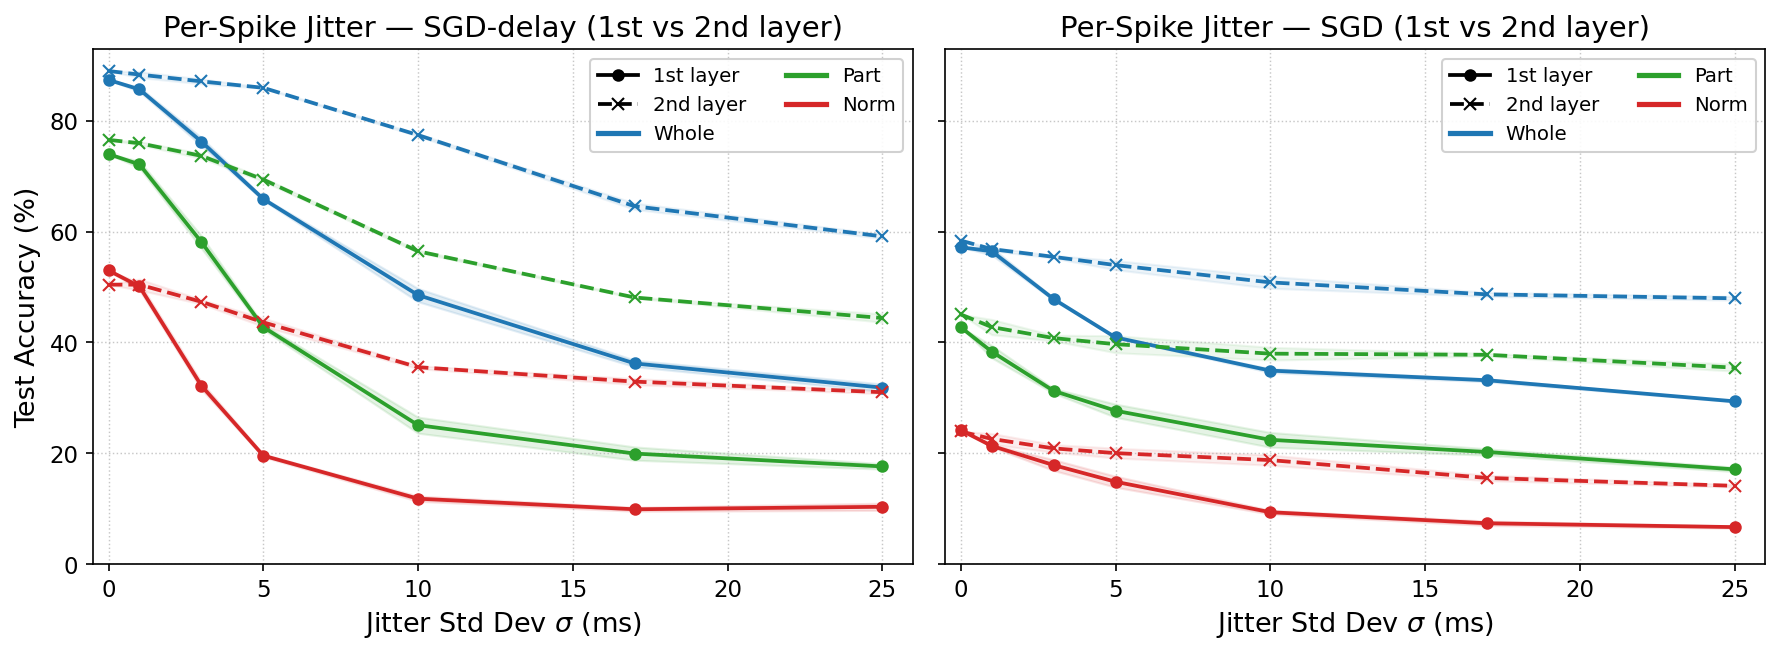

In [2]:
J1 = pathlib.Path("jitter/1stLayer_log")
J2 = pathlib.Path("jitter/2ndLayer_log")

jitter_delay_1 = {
    k: load_sweep(J1 / f"jitter_{k.lower()}_delay_jitter_sweep_results.json")
    for k in DATASETS
}
jitter_delay_2 = {
    k: load_sweep(J2 / f"jitter_2ndLayer_{k.lower()}_delay_evalOnly_jitter_sweep_results.json")
    for k in DATASETS
}
jitter_nod_1 = {
    k: load_sweep(J1 / f"jitter_{k.lower()}_nodelay_jitter_sweep_results.json")
    for k in DATASETS
}
jitter_nod_2 = {
    k: load_sweep(J2 / f"jitter_2ndLayer_{k.lower()}_nodelay_evalOnly_jitter_sweep_results.json")
    for k in DATASETS
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

plot_cross_layer(axes[0], jitter_delay_1, jitter_delay_2,
                 title="Per-Spike Jitter — SGD-delay (1st vs 2nd layer)",
                 xlabel=r"Jitter Std Dev $\sigma$ (ms)",
                 xlim=(-0.5, 26))
axes[0].set_ylabel("Test Accuracy (%)")
add_legend(axes[0])

plot_cross_layer(axes[1], jitter_nod_1, jitter_nod_2,
                 title="Per-Spike Jitter — SGD (1st vs 2nd layer)",
                 xlabel=r"Jitter Std Dev $\sigma$ (ms)",
                 xlim=(-0.5, 26))
add_legend(axes[1])

fig.tight_layout()
#plt.savefig("crossLayer_jitter_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3B: Per-Neuron Shift — Cross-Layer

Same Gaussian offset applied to all spikes of a neuron. Sweep: σ = 0 → 25 ms.

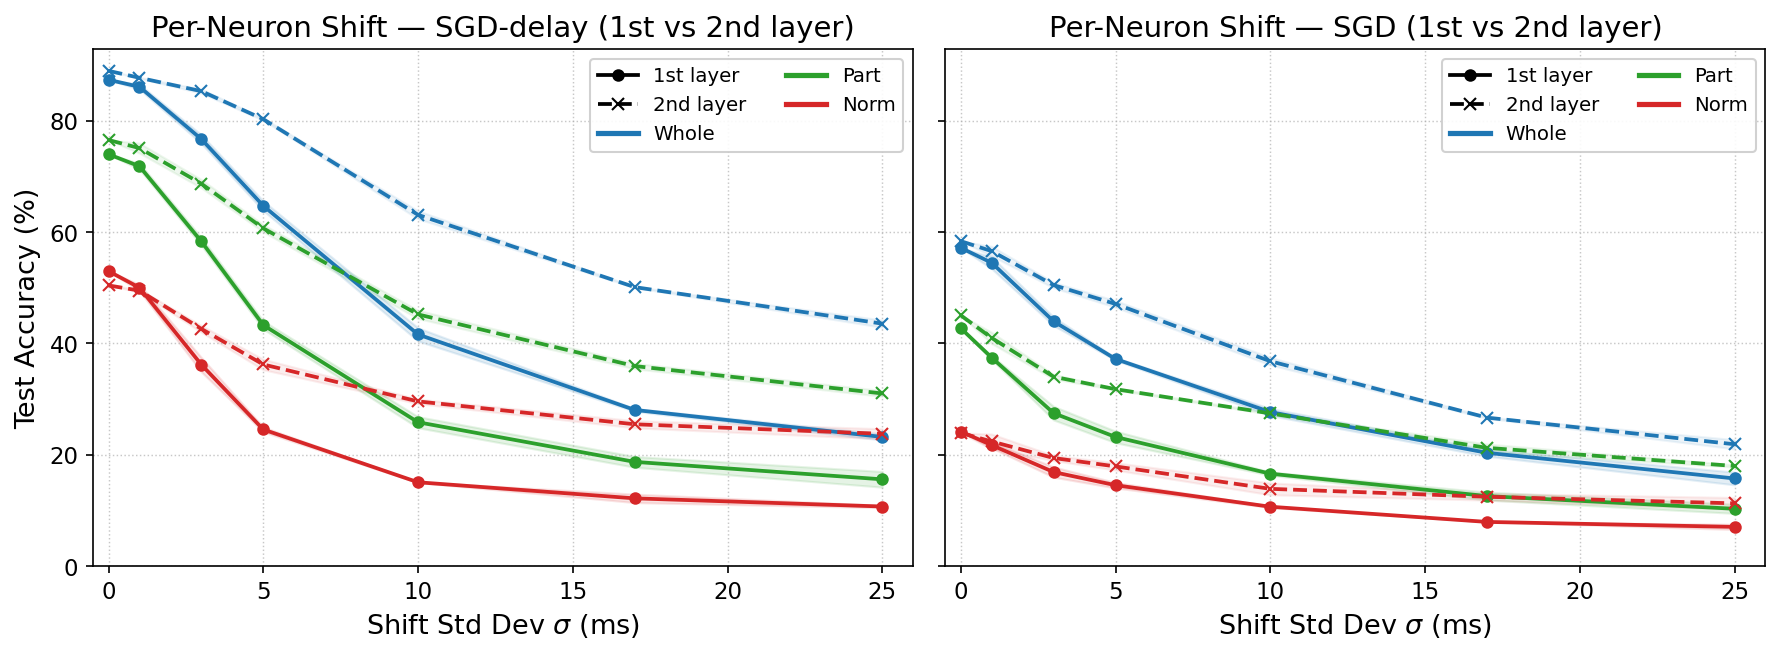

In [3]:
S1 = pathlib.Path("shift/1stLayer_log")
S2 = pathlib.Path("shift/2ndLayer_log")

shift_delay_1 = {
    k: load_sweep(S1 / f"shift_{k.lower()}_delay_shift_sweep_results.json")
    for k in DATASETS
}
shift_delay_2 = {
    k: load_sweep(S2 / f"shift_2ndLayer_{k.lower()}_delay_evalOnly_shift_sweep_results.json")
    for k in DATASETS
}
shift_nod_1 = {
    k: load_sweep(S1 / f"shift_{k.lower()}_nodelay_shift_sweep_results.json")
    for k in DATASETS
}
shift_nod_2 = {
    k: load_sweep(S2 / f"shift_2ndLayer_{k.lower()}_nodelay_evalOnly_shift_sweep_results.json")
    for k in DATASETS
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

plot_cross_layer(axes[0], shift_delay_1, shift_delay_2,
                 title="Per-Neuron Shift — SGD-delay (1st vs 2nd layer)",
                 xlabel=r"Shift Std Dev $\sigma$ (ms)",
                 xlim=(-0.5, 26))
axes[0].set_ylabel("Test Accuracy (%)")
add_legend(axes[0])

plot_cross_layer(axes[1], shift_nod_1, shift_nod_2,
                 title="Per-Neuron Shift — SGD (1st vs 2nd layer)",
                 xlabel=r"Shift Std Dev $\sigma$ (ms)",
                 xlim=(-0.5, 26))
add_legend(axes[1])

fig.tight_layout()
#plt.savefig("crossLayer_shift_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3C: Spike Deletion — Cross-Layer

Each spike independently dropped with probability $p_d$. Sweep: $p_d$ = 0.0 → 0.8.

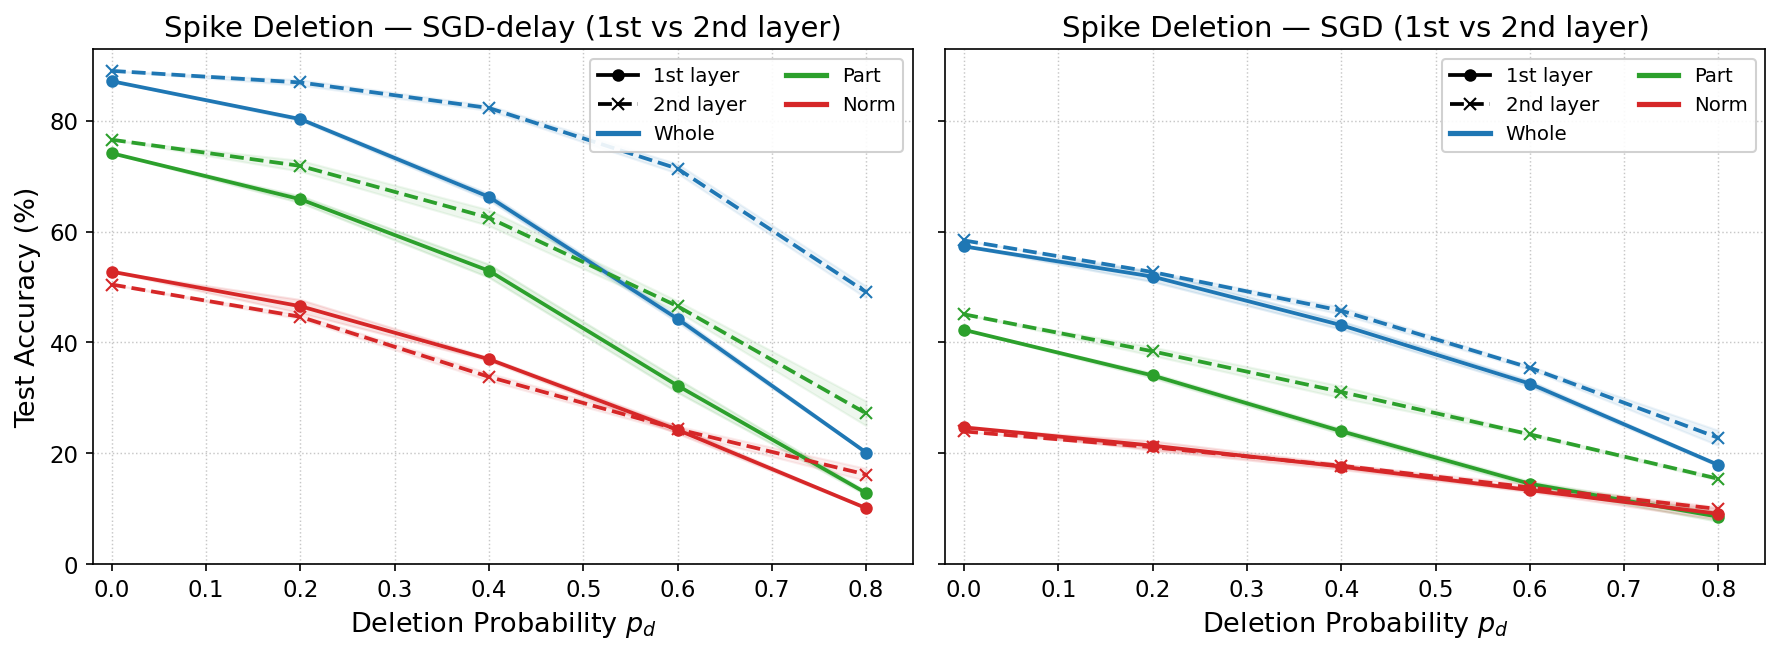

In [4]:
D1 = pathlib.Path("deletion/1stLayer_log")
D2 = pathlib.Path("deletion/2ndLayer_log")

del_delay_1 = {
    k: load_sweep_float(D1 / f"deletion_{k.lower()}_delay_evalOnly_deletion_sweep_results.json")
    for k in DATASETS
}
del_delay_2 = {
    k: load_sweep_float(D2 / f"deletion_2ndLayer_{k.lower()}_delay_evalOnly_deletion_sweep_results.json")
    for k in DATASETS
}
del_nod_1 = {
    k: load_sweep_float(D1 / f"deletion_{k.lower()}_nodelay_evalOnly_deletion_sweep_results.json")
    for k in DATASETS
}
del_nod_2 = {
    k: load_sweep_float(D2 / f"deletion_2ndLayer_{k.lower()}_nodelay_evalOnly_deletion_sweep_results.json")
    for k in DATASETS
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

plot_cross_layer(axes[0], del_delay_1, del_delay_2,
                 title="Spike Deletion — SGD-delay (1st vs 2nd layer)",
                 xlabel=r"Deletion Probability $p_d$",
                 xlim=(-0.02, 0.85))
axes[0].set_ylabel("Test Accuracy (%)")
add_legend(axes[0])

plot_cross_layer(axes[1], del_nod_1, del_nod_2,
                 title="Spike Deletion — SGD (1st vs 2nd layer)",
                 xlabel=r"Deletion Probability $p_d$",
                 xlim=(-0.02, 0.85))
add_legend(axes[1])

fig.tight_layout()
#plt.savefig("crossLayer_deletion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4A: Time Reversal — Cross-Layer

Spike trains time-reversed within each sample's active window at perturbation level $f$.
Sweep: $f$ = 0.0 → 1.0.

Each plot shows the **reversal** condition (solid ●, 1st layer) vs (dashed ×, 2nd layer), and the **no_reversal** condition likewise, for one training variant (SGD-delay or SGD).

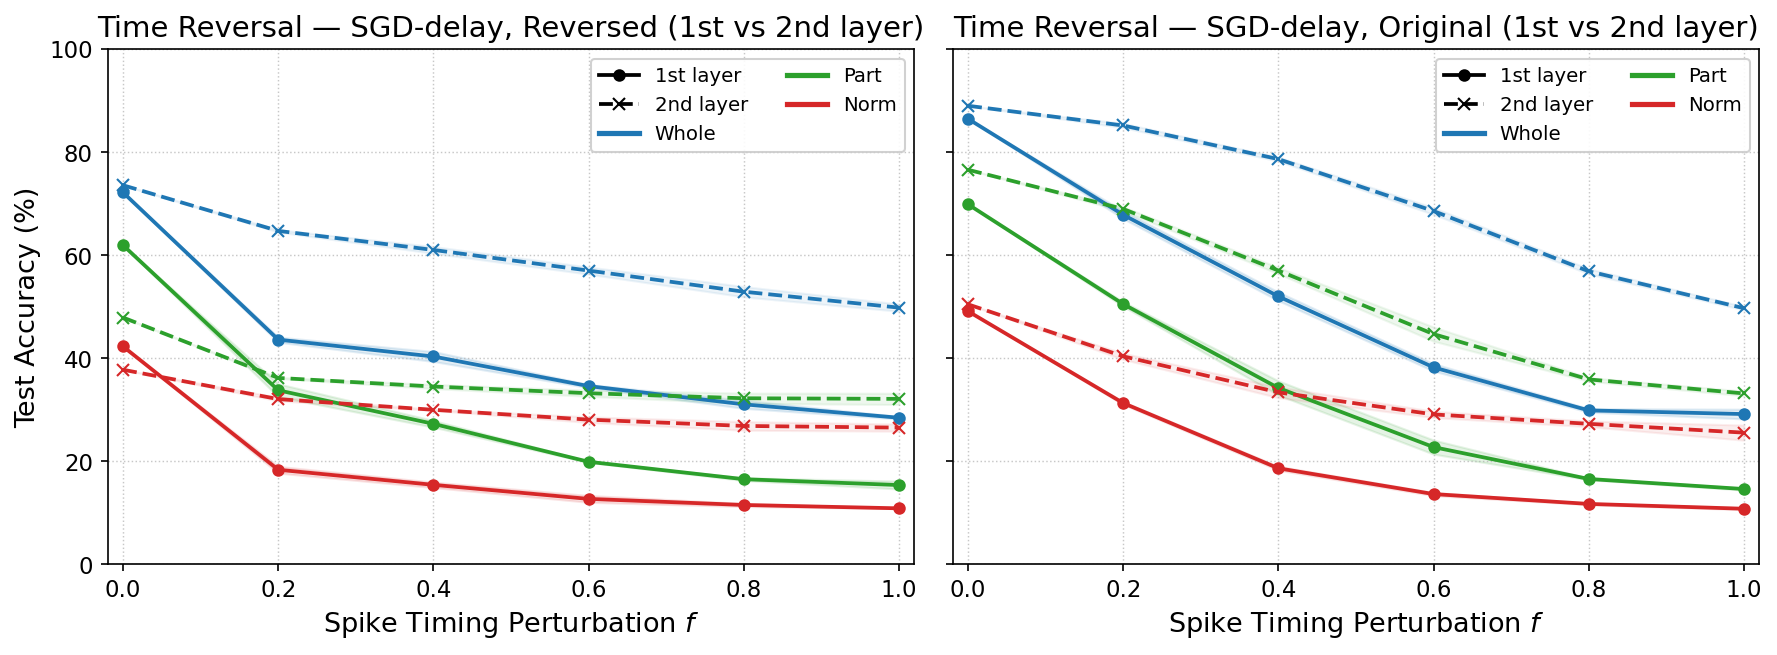

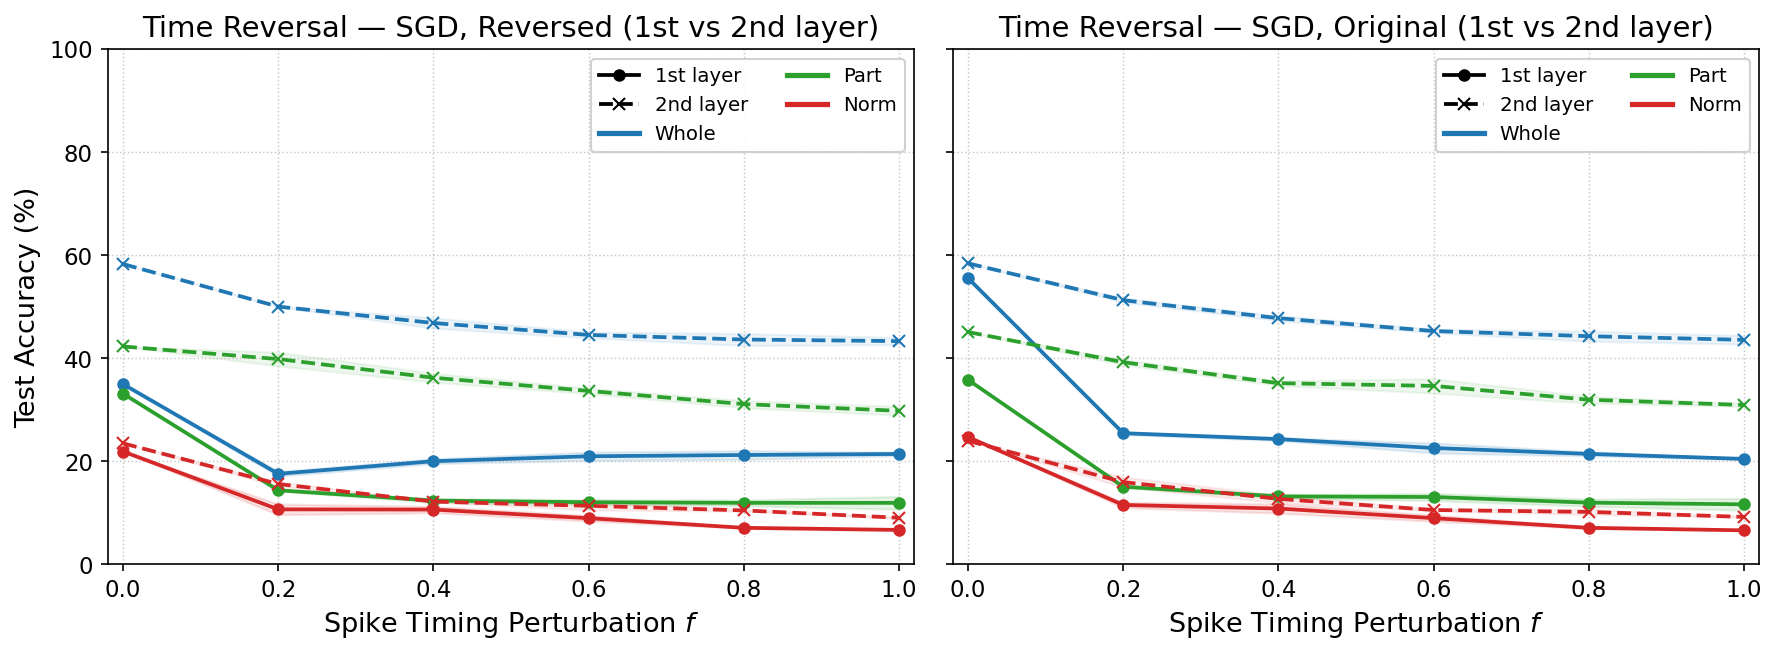

In [5]:
I1 = pathlib.Path("inverse/1stLayer_log")
I2 = pathlib.Path("inverse/2ndLayer_log")

INV1_FILES = {
    (k, delay): I1 / f"shd_{k.lower()}_{'delay' if delay else 'nodelay'}_reversal_sweep_results.json"
    for k in DATASETS for delay in [True, False]
}
INV2_FILES = {
    (k, delay): I2 / f"inverse_2ndLayer_{k.lower()}_{'delay' if delay else 'nodelay'}_evalOnly_reversal_sweep_results.json"
    for k in DATASETS for delay in [True, False]
}


def plot_reversal_cross(
    ax, use_delay: bool, condition: str, title: str
):
    """One axes: overlay reversal condition across 1st layer (solid) and 2nd layer (dashed)."""
    for key in DATASETS:
        xs1, m1, std1 = load_reversal_sweep(INV1_FILES[(key, use_delay)], condition)
        ax.plot(xs1, m1, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
        ax.fill_between(xs1, m1 - std1, m1 + std1, color=COLORS[key], alpha=0.12)

        xs2, m2, std2 = load_reversal_sweep(INV2_FILES[(key, use_delay)], condition)
        ax.plot(xs2, m2, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
        ax.fill_between(xs2, m2 - std2, m2 + std2, color=COLORS[key], alpha=0.08)

    ax.set_title(title)
    ax.set_xlabel(r"Spike Timing Perturbation $f$")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)


# ---- SGD-delay: reversal vs no_reversal, cross-layer ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
plot_reversal_cross(axes[0], use_delay=True, condition="reversal",
                    title="Time Reversal — SGD-delay, Reversed (1st vs 2nd layer)")
axes[0].set_ylabel("Test Accuracy (%)")
add_legend(axes[0])

plot_reversal_cross(axes[1], use_delay=True, condition="no_reversal",
                    title="Time Reversal — SGD-delay, Original (1st vs 2nd layer)")
add_legend(axes[1])

fig.tight_layout()
#plt.savefig("crossLayer_inverse_delay_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- SGD (no delay): reversal vs no_reversal, cross-layer ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
plot_reversal_cross(axes[0], use_delay=False, condition="reversal",
                    title="Time Reversal — SGD, Reversed (1st vs 2nd layer)")
axes[0].set_ylabel("Test Accuracy (%)")
add_legend(axes[0])

plot_reversal_cross(axes[1], use_delay=False, condition="no_reversal",
                    title="Time Reversal — SGD, Original (1st vs 2nd layer)")
add_legend(axes[1])

fig.tight_layout()
#plt.savefig("crossLayer_inverse_nod_comparison.png", dpi=150, bbox_inches="tight")
plt.show()